In [ ]:
!pip install nibabel pydicom h5py

## Data Inspection and exploration

In [ ]:
import os
import nibabel as nib
import numpy as np
from tqdm import tqdm
from collections import Counter

In [ ]:
DATA_ROOT = "/kaggle/input/datasets/soumyamakkar/ixi-brain-mri-t1-t2"  # adjust if needed

In [ ]:
print(os.listdir(DATA_ROOT)[:10])

In [ ]:
def get_ixi_paths_fixed(root):
    nii_paths = []

    for subject in os.listdir(root):
        sub_path = os.path.join(root, subject)
        if not os.path.isdir(sub_path):
            continue

        for scan_type in ["T1", "T2"]:
            scan_path = os.path.join(sub_path, scan_type, "NIfTI")

            if not os.path.exists(scan_path):
                continue

            for outer in os.listdir(scan_path):
                outer_path = os.path.join(scan_path, outer)

                # 🔑 This is actually a folder
                if os.path.isdir(outer_path):
                    for f in os.listdir(outer_path):
                        if f.endswith(".nii"):
                            full_path = os.path.join(outer_path, f)

                            # skip tiny/corrupt
                            if os.path.getsize(full_path) < 10000:
                                continue

                            nii_paths.append((scan_type, full_path))

    return nii_paths


ixi_paths = get_ixi_paths_fixed(DATA_ROOT)
print("Total valid files:", len(ixi_paths))

In [ ]:
def inspect_ixi(ixi_paths, max_samples=2000):
    shapes = []
    spacings = []
    scan_types = []

    intensity_min = []
    intensity_max = []
    intensity_mean = []
    intensity_std = []

    p1_vals = []
    p99_vals = []

    depths = []
    bad_volumes = 0

    for scan_type, path in tqdm(ixi_paths[:max_samples]):
        try:
            img = nib.load(path)
            data = img.get_fdata()

            # Basic
            shapes.append(data.shape)
            spacings.append(img.header.get_zooms())
            scan_types.append(scan_type)

            # Depth
            depths.append(data.shape[2])

            # Intensity stats
            intensity_min.append(np.min(data))
            intensity_max.append(np.max(data))
            intensity_mean.append(np.mean(data))
            intensity_std.append(np.std(data))

            # Percentiles (VERY IMPORTANT)
            p1 = np.percentile(data, 1)
            p99 = np.percentile(data, 99)
            p1_vals.append(p1)
            p99_vals.append(p99)

            # Detect bad volumes (almost empty)
            if np.mean(data) < 1e-3 or np.std(data) < 1e-3:
                bad_volumes += 1

        except Exception as e:
            print(f"Error loading {path}: {e}")

    print("\n===== IXI ADVANCED STATS =====")
    print(f"Samples checked: {len(shapes)}")
    print(f"Bad volumes detected: {bad_volumes}")

    # Shapes
    print("\n🧠 Shape Info:")
    print(f"Unique shapes: {len(set(shapes))}")
    print(f"Examples: {list(set(shapes))[:5]}")

    # Depth
    print("\n📦 Depth (Z-axis):")
    print(f"Min: {np.min(depths)}, Max: {np.max(depths)}, Mean: {np.mean(depths):.2f}")

    # Spacing
    print("\n📏 Spacing Info:")
    print(f"Examples: {list(set(spacings))[:5]}")

    # Scan types
    print("\n🧪 Scan Types:")
    print(Counter(scan_types))

    # Intensity stats
    print("\n🌈 Intensity Stats:")
    print(f"Min (avg): {np.mean(intensity_min):.2f}")
    print(f"Max (avg): {np.mean(intensity_max):.2f}")
    print(f"Mean (avg): {np.mean(intensity_mean):.2f}")
    print(f"Std (avg): {np.mean(intensity_std):.2f}")

    # Percentiles (KEY FOR NORMALIZATION)
    print("\n📊 Percentiles (for normalization):")
    print(f"P1 avg: {np.mean(p1_vals):.2f}")
    print(f"P99 avg: {np.mean(p99_vals):.2f}")


inspect_ixi(ixi_paths)

# Data Preprocessing

To ensure consistency across heterogeneous MRI datasets, a unified preprocessing pipeline was applied to all volumes prior to model training.

First, all MRI volumes were resampled to an isotropic spatial resolution of 1.0 × 1.0 × 1.0 mm³ using trilinear interpolation. This step standardizes voxel spacing across datasets acquired with different imaging protocols and ensures spatial consistency.

Volumes with insufficient depth (less than 100 slices) were excluded to remove incomplete or corrupted scans that could negatively impact model training.

Next, spatial normalization was performed via center cropping. All volumes were cropped to a fixed size of 192 × 192 × 128, effectively removing irrelevant background regions while preserving anatomical structures of interest.

Intensity normalization was then applied on a per-volume basis. Specifically, voxel intensities were clipped to the 1st and 99th percentiles to suppress extreme outliers, followed by min-max normalization to scale values to the range [0, 1]. This approach accounts for variability in MRI intensity distributions across scanners and acquisition protocols.

To enable efficient training, 3D volumes were decomposed into 2D axial slices. Each slice was treated as an independent sample, allowing the use of 2D convolutional architectures while maintaining sufficient anatomical context. Slices with negligible signal intensity were discarded to avoid introducing non-informative samples.

Finally, the processed slices were stored in NumPy format (float32) for efficient loading during training.

Notably, brain-specific preprocessing steps such as skull stripping and template registration were intentionally omitted to ensure that the pipeline generalizes across multiple anatomical regions, including both brain and knee MRI datasets.

## Preprocessing

## Resampling

## Center Cropping

## Intensity Normalization

## Slice Extraction

In [1]:
import os
import random
import numpy as np
import nibabel as nib
from tqdm import tqdm
from scipy.ndimage import zoom

# Paths
DATA_ROOT = "/kaggle/input/datasets/soumyamakkar/ixi-brain-mri-t1-t2"
SAVE_ROOT = "/kaggle/working/processed_ixi"

# Output structure
TRAIN_DIR = os.path.join(SAVE_ROOT, "train")
VAL_DIR = os.path.join(SAVE_ROOT, "val")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(VAL_DIR, exist_ok=True)

# Config
TARGET_SPACING = (1.0, 1.0, 1.0)
TARGET_SHAPE = (192, 192, 128)
MIN_DEPTH = 100

SLICES_PER_VOLUME = 64
MIN_SLICE_MEAN = 0.01

random.seed(42)

In [2]:
def collect_ixi_paths(root):
    paths = []

    for subject in os.listdir(root):
        sub_path = os.path.join(root, subject)

        if not os.path.isdir(sub_path):
            continue

        for scan_type in ["T1", "T2"]:
            nii_dir = os.path.join(sub_path, scan_type, "NIfTI")

            if not os.path.exists(nii_dir):
                continue

            for file in os.listdir(nii_dir):
                file_path = os.path.join(nii_dir, file)

                if os.path.isdir(file_path):
                    for subfile in os.listdir(file_path):
                        if subfile.endswith(".nii"):
                            paths.append((scan_type, os.path.join(file_path, subfile)))

                elif file.endswith(".nii"):
                    paths.append((scan_type, file_path))

    return paths


ixi_paths = collect_ixi_paths(DATA_ROOT)
print("Total files:", len(ixi_paths))

Total files: 1159


## Split T1 AND T2 and sample


In [3]:
# Separate
t1_paths = [p for p in ixi_paths if p[0] == "T1"]
t2_paths = [p for p in ixi_paths if p[0] == "T2"]

print("T1:", len(t1_paths), "T2:", len(t2_paths))

# Shuffle
random.shuffle(t1_paths)
random.shuffle(t2_paths)

# Select
train_t1 = t1_paths[:200]
train_t2 = t2_paths[:200]

val_t1 = t1_paths[200:250]
val_t2 = t2_paths[200:250]

train_paths = train_t1 + train_t2
val_paths = val_t1 + val_t2

print("Train:", len(train_paths))
print("Val:", len(val_paths))

T1: 581 T2: 578
Train: 400
Val: 100


In [4]:
def resample_volume(volume, current_spacing, target_spacing=(1,1,1)):
    resize_factor = np.array(current_spacing) / np.array(target_spacing)
    new_shape = np.round(volume.shape * resize_factor).astype(int)
    zoom_factor = new_shape / volume.shape

    return zoom(volume, zoom_factor, order=1)


def center_crop(volume, target_shape=(192,192,128)):
    x, y, z = volume.shape
    tx, ty, tz = target_shape

    start_x = max((x - tx) // 2, 0)
    start_y = max((y - ty) // 2, 0)
    start_z = max((z - tz) // 2, 0)

    return volume[
        start_x:start_x+tx,
        start_y:start_y+ty,
        start_z:start_z+tz
    ]


def normalize(volume):
    p1, p99 = np.percentile(volume, (1, 99))

    if p99 - p1 < 1e-5:
        return None

    volume = np.clip(volume, p1, p99)
    volume = (volume - p1) / (p99 - p1)

    return volume

In [5]:
def smart_sample_slices(volume, num_slices=64):
    z = volume.shape[2]

    slices = []

    # Define regions
    edge_portion = int(0.15 * z)
    center_portion = int(0.7 * z)

    edge_indices = list(range(0, edge_portion)) + list(range(z - edge_portion, z))
    center_indices = list(range(edge_portion, z - edge_portion))

    # Split sampling budget
    num_center = int(num_slices * 0.7)
    num_edge = num_slices - num_center

    # Sample
    center_samples = np.random.choice(center_indices, num_center, replace=False)
    edge_samples = np.random.choice(edge_indices, num_edge, replace=False)

    indices = np.concatenate([center_samples, edge_samples])
    indices = np.sort(indices)

    # Extract slices
    for i in indices:
        sl = volume[:, :, i]

        if np.mean(sl) < MIN_SLICE_MEAN:
            continue

        slices.append(sl.astype(np.float32))

    return slices

In [6]:
def process_dataset(paths, save_root):
    processed = 0
    skipped = 0

    for scan_type, path in tqdm(paths):
        try:
            img = nib.load(path)
            volume = img.get_fdata()

            # Skip shallow volumes
            if volume.shape[2] < MIN_DEPTH:
                skipped += 1
                continue

            spacing = img.header.get_zooms()[:3]

            # STEP 1: Resample
            volume = resample_volume(volume, spacing, TARGET_SPACING)

            # STEP 2: Crop
            volume = center_crop(volume, TARGET_SHAPE)

            if volume.shape != TARGET_SHAPE:
                skipped += 1
                continue

            # STEP 3: Normalize
            volume = normalize(volume)

            if volume is None:
                skipped += 1
                continue

            # STEP 4: Random slice sampling
            slices = smart_sample_slices(volume, SLICES_PER_VOLUME)

            if len(slices) == 0:
                skipped += 1
                continue

            # Save
            save_dir = os.path.join(save_root, scan_type)
            os.makedirs(save_dir, exist_ok=True)

            base_name = os.path.basename(path).replace(".nii", "")

            for i, sl in enumerate(slices):
                save_path = os.path.join(save_dir, f"{base_name}_slice_{i:03d}.npy")
                np.save(save_path, sl)

            processed += 1

        except Exception as e:
            print(f"Error: {path} -> {e}")
            skipped += 1

    print("\nDone")
    print("Processed:", processed)
    print("Skipped:", skipped)

In [7]:
print("Processing TRAIN...")
process_dataset(train_paths, TRAIN_DIR)

Processing TRAIN...


100%|██████████| 400/400 [14:20<00:00,  2.15s/it]


Done
Processed: 400
Skipped: 0



===== T1 =====


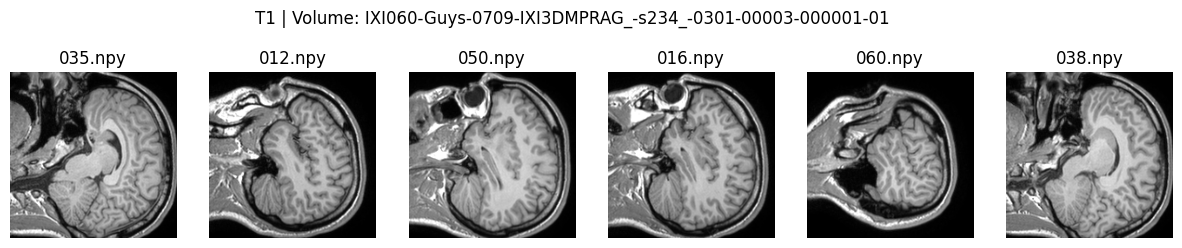

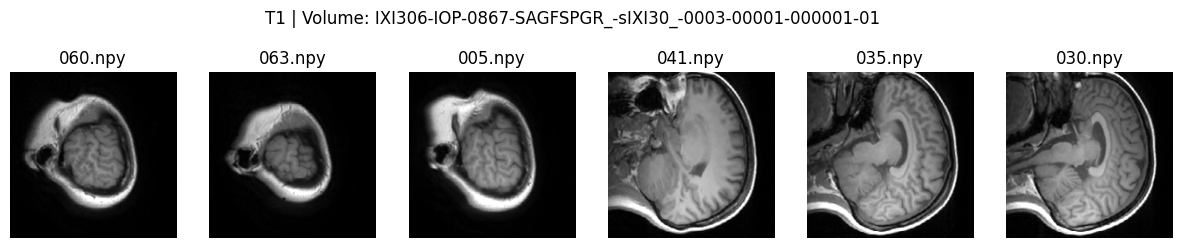

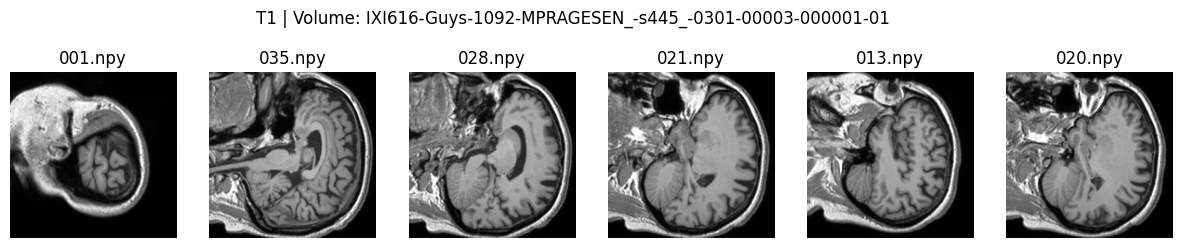


===== T2 =====


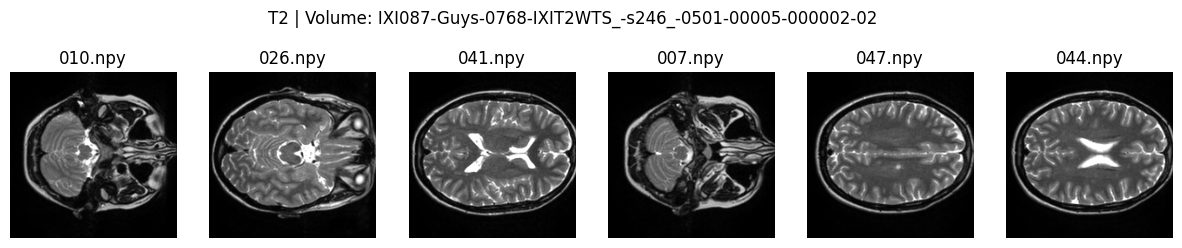

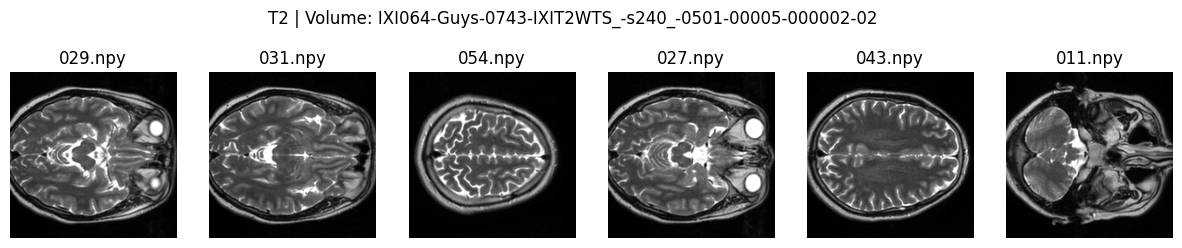

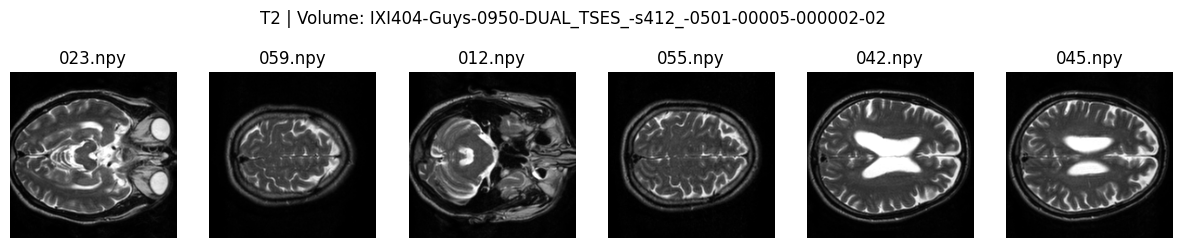

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# Pick train or val
DATA_DIR = "/kaggle/working/processed_ixi/train"   # change to val if needed

def visualize_random_samples(data_dir, num_samples=3, slices_per_sample=6):
    scan_types = ["T1", "T2"]

    for scan_type in scan_types:
        folder = os.path.join(data_dir, scan_type)

        if not os.path.exists(folder):
            print(f"{scan_type} not found")
            continue

        files = os.listdir(folder)

        # Group by volume name
        volume_dict = {}
        for f in files:
            base = "_".join(f.split("_slice_")[:-1])
            volume_dict.setdefault(base, []).append(f)

        volume_keys = list(volume_dict.keys())
        random.shuffle(volume_keys)

        print(f"\n===== {scan_type} =====")

        for v in volume_keys[:num_samples]:
            slice_files = volume_dict[v]

            # pick random slices from this volume
            chosen = random.sample(slice_files, min(slices_per_sample, len(slice_files)))

            fig, axes = plt.subplots(1, len(chosen), figsize=(15, 3))

            if len(chosen) == 1:
                axes = [axes]

            for i, f in enumerate(chosen):
                path = os.path.join(folder, f)
                img = np.load(path)

                axes[i].imshow(img, cmap="gray")
                axes[i].set_title(f"{f.split('_')[-1]}")
                axes[i].axis("off")

            plt.suptitle(f"{scan_type} | Volume: {v}", fontsize=12)
            plt.show()


# Run
visualize_random_samples(DATA_DIR)

Min: 0.0
Max: 1.0
Mean: 0.27851444
Std: 0.2763477


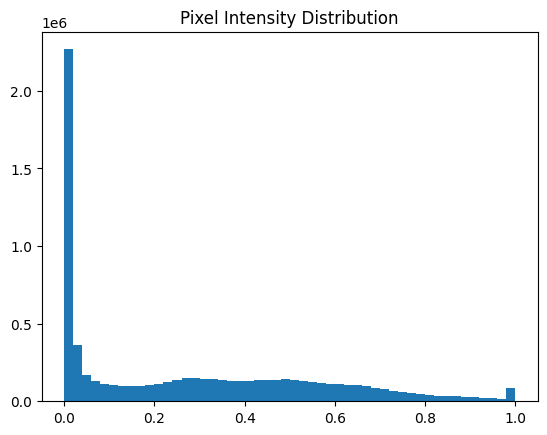

In [9]:
def check_distribution(data_dir, num_samples=100):
    all_vals = []

    for scan_type in ["T1", "T2"]:
        folder = os.path.join(data_dir, scan_type)
        files = os.listdir(folder)

        for f in random.sample(files, min(num_samples, len(files))):
            img = np.load(os.path.join(folder, f))
            all_vals.append(img.flatten())

    all_vals = np.concatenate(all_vals)

    print("Min:", np.min(all_vals))
    print("Max:", np.max(all_vals))
    print("Mean:", np.mean(all_vals))
    print("Std:", np.std(all_vals))

    plt.hist(all_vals, bins=50)
    plt.title("Pixel Intensity Distribution")
    plt.show()


check_distribution(DATA_DIR)

In [10]:
print("Processing VALIDATION...")
process_dataset(val_paths, VAL_DIR)

Processing VALIDATION...


100%|██████████| 100/100 [03:28<00:00,  2.08s/it]


Done
Processed: 100
Skipped: 0


In [11]:
import os

def count_processed_data(root):
    total = 0

    for split in ["train", "val"]:
        print(f"\n📂 {split.upper()}")

        split_path = os.path.join(root, split)
        split_total = 0

        for scan_type in ["T1", "T2"]:
            path = os.path.join(split_path, scan_type)

            if not os.path.exists(path):
                continue

            files = [f for f in os.listdir(path) if f.endswith(".npy")]
            count = len(files)

            print(f"  {scan_type}: {count}")
            split_total += count

        print(f"  Total ({split}): {split_total}")
        total += split_total

    print(f"\n🔥 GRAND TOTAL SLICES: {total}")


# Run
count_processed_data("/kaggle/working/processed_ixi")


📂 TRAIN
  T1: 12800
  T2: 12800
  Total (train): 25600

📂 VAL
  T1: 3200
  T2: 3200
  Total (val): 6400

🔥 GRAND TOTAL SLICES: 32000


In [12]:
import os  # Added missing import

def count_unique_volumes(root):
    # Removed: from collections import set (set is a built-in)
    
    volume_ids = set()

    for split in ["train", "val"]:
        for scan_type in ["T1", "T2"]:
            path = os.path.join(root, split, scan_type)

            if not os.path.exists(path):
                continue

            for f in os.listdir(path):
                if f.endswith(".npy"):
                    # Extract ID before the '_slice_' delimiter
                    vol_id = f.split("_slice_")[0]
                    volume_ids.add(vol_id)

    print(f"🧠 Unique volumes used: {len(volume_ids)}")
count_unique_volumes("/kaggle/working/processed_ixi")

🧠 Unique volumes used: 500


In [13]:
import shutil

shutil.make_archive(
    "/kaggle/working/processed_ixi",
    'zip',
    "/kaggle/working/processed_ixi"
)

print("✅ Zip created at: /kaggle/working/processed_ixi.zip")

✅ Zip created at: /kaggle/working/processed_ixi.zip


In [15]:
import kagglehub

handle = 'kaustubhratna/Preprocessed-ixi-brain'
local_dataset_dir = '/kaggle/working/processed_ixi.zip'

# Create a new dataset
kagglehub.dataset_upload(handle, local_dataset_dir)

# You can then create a new version of this dataset and include version notes.
# kagglehub.dataset_upload(handle, local_dataset_dir, version_notes='improved data')

# You can also specify a list of patterns for files/dirs to ignore.
# These patterns are combined with 'kagglehub.datasets.DEFAULT_IGNORE_PATTERNS'
# to determine which files and directories to exclude. 
# To ignore entire directories, include a trailing slash (/) in the pattern.
# kagglehub.dataset_upload(handle, local_dataset_dir, ignore_patterns=["original/", "*.tmp"])


Uploading Dataset https://api.kaggle.com/datasets/kaustubhratna/Preprocessed-ixi-brain ...
Starting upload for file /kaggle/working/processed_ixi.zip


Uploading: 100%|██████████| 4.06G/4.06G [01:30<00:00, 44.9MB/s]

Upload successful: /kaggle/working/processed_ixi.zip (4GB)


Your dataset has been created.
Files are being processed...
See at: https://api.kaggle.com/datasets/kaustubhratna/Preprocessed-ixi-brain
